In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
from math import radians
import sklearn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, roc_auc_score, roc_curve, precision_recall_curve
import seaborn as sns
import matplotlib.pyplot as plt
import shap


C:\Users\KevinPC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
is_cuda_active = torch.cuda.is_available()
print(f"{is_cuda_active}")

device = torch.device("cuda")


True


In [3]:
np.random.seed(42)

In [9]:
#preprocessing
important_cols = ['cc_num', 'category', 'amt', 'lat', 'long', 'city_pop', 'dob', 'unix_time', 'merch_lat', 'merch_long', 'trans_date_trans_time', 'is_fraud']

pp_data = pd.read_csv("dataset/fraudTrain.csv")[important_cols]
pp_data = pp_data.dropna()
#preprocessing the data
pp_data['trans_datetime']   = pd.to_datetime(pp_data['trans_date_trans_time'])
pp_data['hour']             = pp_data['trans_datetime'].dt.hour
pp_data['day_of_week']      = pp_data['trans_datetime'].dt.dayofweek
pp_data['month']            = pp_data['trans_datetime'].dt.month

#remove the date data
pp_data.drop(columns=['trans_date_trans_time', 'trans_datetime'], inplace=True)

#get age from data
pp_data['dob'] = pd.to_datetime(pp_data['dob'])
ref_date = pd.to_datetime('2019-01-01')
pp_data['age'] = (ref_date - pp_data['dob']).dt.days // 365
pp_data.drop(columns=['dob'], inplace=True)

pp_data["vulernable"] = (pp_data["age"]>= 60).astype(int)

#get distance between cardholder and merchant
def haversine_vec(lat1, long1, lat2, long2):
    #Earth's radius in km
    R = 6371
    lat1, long1, lat2, long2 = map(np.radians, [lat1, long1, lat2, long2])
    diff_lat = lat2 - lat1
    diff_long = long2 - long1
    a = np.sin(diff_lat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(diff_long/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

pp_data['dist_to_merch'] = haversine_vec(pp_data['lat'], pp_data['long'], pp_data['merch_lat'], pp_data['merch_long'])
pp_data.drop(columns = ['lat', 'long', 'merch_lat', 'merch_long'], inplace=True)
#pp_data["ageGroups"] = pd.cut(pp_data["age"], bins=[0,20,30,40,50,60,100], labels=["<20", "21-30", "31-40","41-50", "51-60", "60+"]) #using for graph
#scale numerical features
scale_cols = ['amt', 'city_pop', 'unix_time', 'age', 'dist_to_merch', 'hour', 'day_of_week', 'month']
scaler = StandardScaler()
pp_data[scale_cols] = scaler.fit_transform(pp_data[scale_cols])

#data that only has normal transactions used to train the autoencoder
pp_normal_trans = pp_data[pp_data['is_fraud'] == 0].drop(columns=['is_fraud'])

pp_data.to_csv('fraudTrain_processed.csv', index=False)
pp_normal_trans.to_csv('normalTrain.csv', index=False)

#added this bc otherwise giving me issues - need for transformer!
pp_data["category"] = LabelEncoder().fit_transform(pp_data["category"].astype(str))

#build sequences for LSTM
seq_len = 5

data_sorted_unixtime = pp_data.sort_values('unix_time')
sequences = []
labels = []

for card_id, group, in data_sorted_unixtime.groupby('cc_num'):
    #drops cc_num and is_fraud columns before feeding to the LSTM
    features = group.drop(columns=['cc_num', 'is_fraud']).values
    target = group['is_fraud'].values
    for i in range(len(features) - seq_len):
        sequences.append(features[i:i+seq_len])
        labels.append(float(target[i+seq_len]))

x_seq = np.array(sequences)
y_seq = np.array(labels)

n_features = x_seq.shape[2]

In [ ]:
data = pd.read_csv("dataset/fraudTrain.csv")
cat = sorted(data["category"].dropna().unique())

mapped= {c: x for c, x in enumerate(cat)}

catfraud = (data.groupby("category")["is_fraud"].mean().reset_index()).sort_values("is_fraud")
catlabel = catfraud["label"] = catfraud["category"].map(mapped)

plt.figure(figsize=(15,6))
plt.bar(catfraud["label"], catfraud["is_fraud"], color = "green")

plt.xlabel("category")
plt.ylabel("Fraud %")

plt.show()


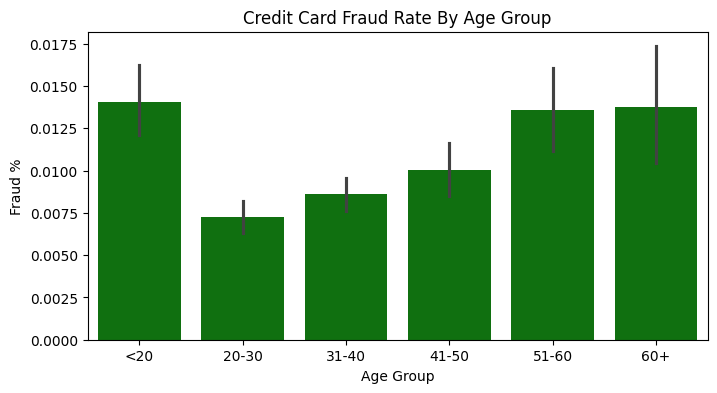

In [ ]:
#Is age a significant factor when it comes to being victim of credit card schemes?

pp_data["ageGroups"] = pd.cut(pp_data["age"], bins=6, labels=["<20", "20-30","31-40","41-50","51-60", "60+"])

fig, axis = plt.subplots(figsize=(8,4))

sns.barplot(data=pp_data, x="ageGroups", y = "is_fraud", ax=axis, color="green")

axis.set_title("Credit Card Fraud Rate By Age Group")

axis.set_xlabel("Age Group")
axis.set_ylabel("Fraud %")

plt.show()

In [ ]:
pp_data.drop(columns=["ageGroups"], inplace=True)

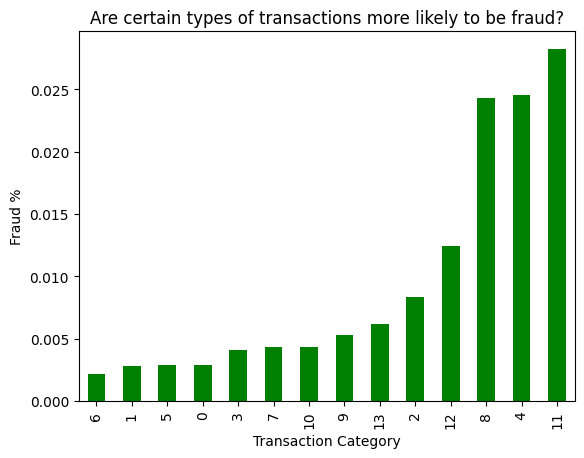

In [ ]:
# Are specific categories of transactions more likely to be fraudulent?

cFakes = pp_data.groupby("category")["is_fraud"].mean()

cFakes = cFakes.sort_values()

cFakes.plot(kind="bar", color="green")

plt.title("Are certain types of transactions more likely to be fraud?")

plt.xlabel("Transaction Category")

plt.ylabel("Fraud %")

plt.show()




In [ ]:
#60 train / 20 val / 20 test!

X_trainVal, X_test, y_trainVal, y_test = train_test_split(x_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq)

X_train, X_val, y_train, y_val = train_test_split(X_trainVal, y_trainVal, test_size=0.25, random_state=42, stratify=y_trainVal)

In [ ]:
#class balances of all sets:

print("Y train set class balance")
print(np.unique(y_train, return_counts=True, return_index=True))

print("Y validation set class balance")
print(np.unique(y_val, return_counts=True, return_index=True))

print("Y test set class balance")
print(np.unique(y_test, return_counts=True, return_index=True))

Y train set class balance
(array([0., 1.]), array([ 0, 71]), array([59674,   568]))
Y validation set class balance
(array([0., 1.]), array([ 0, 90]), array([19891,   190]))
Y test set class balance
(array([0., 1.]), array([ 0, 92]), array([19891,   190]))


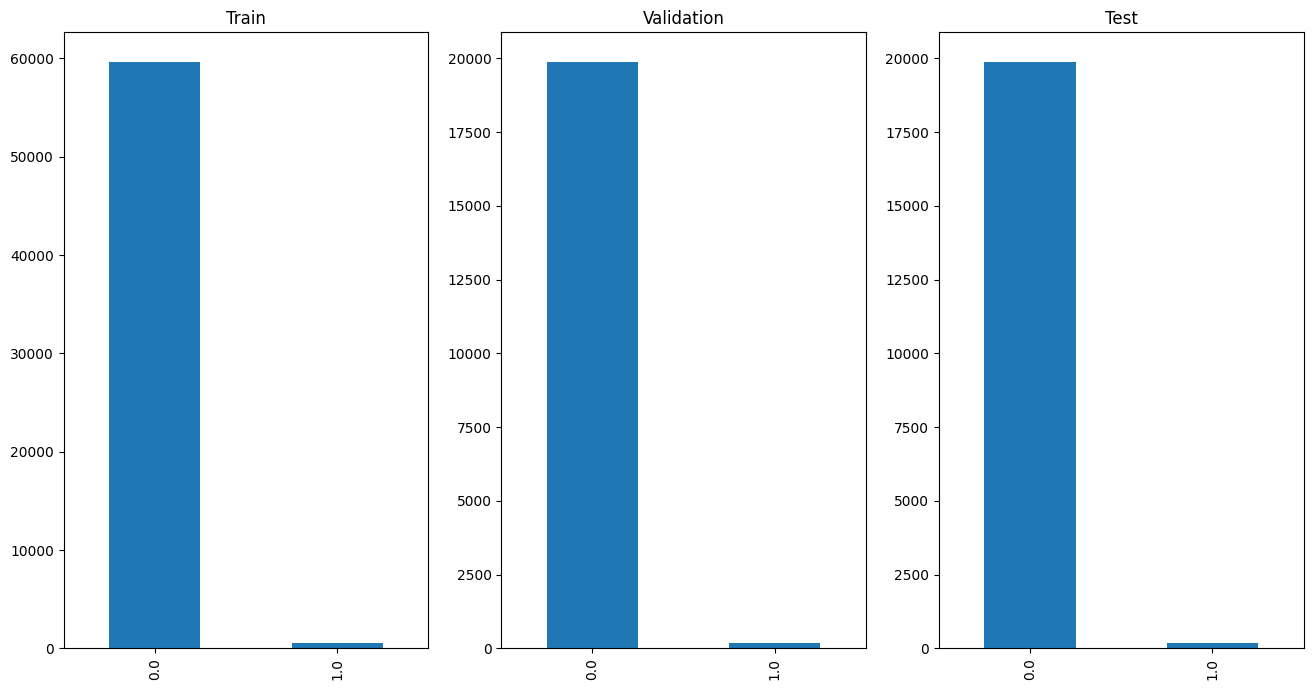

In [ ]:
f, (ax1, ax2 , ax3) = plt.subplots(1,3, figsize=(16, 8))

pd.Series(y_train).value_counts().plot(kind="bar", ax=ax1, title="Train")
pd.Series(y_val).value_counts().plot(kind="bar", ax=ax2, title="Validation")
pd.Series(y_test).value_counts().plot(kind="bar", ax=ax3, title="Test")

plt.show()

In [ ]:
#convert all to tensor


X_train_tensor = torch.tensor(X_train, dtype = torch.float32)

X_trVal_tensor = torch.tensor(X_trainVal, dtype = torch.float32)

X_val_tensor = torch.tensor(X_val, dtype = torch.float32)

X_test_tensor = torch.tensor(X_test, dtype = torch.float32)

y_test_tensor = torch.tensor(y_test, dtype = torch.float32)

y_val_tensor = torch.tensor(y_val, dtype = torch.float32)

y_trVal_tensor = torch.tensor(y_trainVal, dtype = torch.float32)

y_train_tensor = torch.tensor(y_train, dtype = torch.float32)

In [ ]:
trainDataLoader = DataLoader(TensorDataset(X_train_tensor,y_train_tensor), batch_size=256, shuffle=True) #since we used pytorch, these functions batch + shuffle data for training!!


validationDataLoader = DataLoader(TensorDataset(X_val_tensor,y_val_tensor), batch_size=256, shuffle=True)

In [ ]:
negative = (y_train==0) #getting how imbalanced each class is
pos = (y_train==1)


nCount = negative.sum()
pCount = pos.sum()

cap = min(nCount/pCount, 50)
pos_weight = torch.tensor([cap], dtype=torch.float32).to(device)
class_weight = {0:1, 1: nCount/pCount}

In [ ]:
class lstm(nn.Module): #using code similar to what we learned in class here -- we using the last 5 of the user's transactions to classify if the next one is real/fake
  def __init__(self, input_size, hidden_size=128, dropout=0.3):
    super().__init__()
    self.lstm = nn.LSTM(input_size, hidden_size, num_layers=2, batch_first=True, dropout=dropout)

   # self.lstm = nn.LSTM(inputSize, hiddenSize, batch_first=True)
    self.dropout = nn.Dropout(dropout)
    self.fc = nn.Linear(hidden_size, 1)

  def forward(self, x):

    _, (hidden, _) = self.lstm(x)
    out = self.dropout(hidden[-1]) #using the hidden state is what helps with memory
    return self.fc(out).squeeze(1)



In [ ]:
class tsf(nn.Module): #using the model from "Attention is All You Need" as reference


  def __init__(self, input_size, d_model = 64, num_heads = 8, dim_feedforward=128, num_layers=2, dropout=0.2):

    super().__init__()

    self.input_val = nn.Linear(input_size, d_model) #taking the features and converting them into dimensions that can be identified by the transformer
    en = nn.TransformerEncoderLayer(d_model=d_model, nhead=num_heads, dim_feedforward = dim_feedforward, dropout = dropout, batch_first=True)

    self.transformer = nn.TransformerEncoder(en, num_layers=num_layers)
    self.model = nn.Sequential(nn.Linear(d_model, 64), nn.ReLU(), nn.Dropout(dropout), nn.Linear(64,1)) #this is the classifier part! the info from the tsf is used here to identify if a transaction is fake or real

  def forward(self, x):

    x = self.input_val(x)
    x = self.transformer(x)
    x = x.mean(dim=1)
    return self.model(x).squeeze(1)

In [ ]:
class lstmTsf(nn.Module):

  def __init__(self, input_size, lstm_hidden=128, d_model=64, num_heads=8, dim_feedforward=128, num_transformer_layers=2, dropout=0.3):

    super().__init__()

    self.lstm = nn.LSTM(input_size, lstm_hidden, num_layers=2, batch_first=True, dropout = dropout)

    self.p = nn.Linear(lstm_hidden, d_model)

    en = nn.TransformerEncoderLayer(d_model=d_model,  nhead= num_heads, dim_feedforward=dim_feedforward, dropout = dropout, batch_first=True)
    self.transformer = nn.TransformerEncoder(en, num_layers=num_transformer_layers)

    self.model = nn.Sequential(nn.Linear(d_model, 64), nn.ReLU(), nn.Dropout(dropout), nn.Linear(64,1))


  def forward(self, x):

    output, _ = self.lstm(x)

    x = self.p(output)
    x = self.transformer(x)
    x=x.mean(dim=1)

    return self.model(x).squeeze(1)

In [ ]:
def trainAll(model, epochs=25, lr=0.0001, patience=5):

  op = torch.optim.Adam(model.parameters(), lr=lr)

  cri = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

  reducer = torch.optim.lr_scheduler.ReduceLROnPlateau(op, patience=2, factor=.5)

  bestvLoss = float("inf")

  bestW = None
  imp0 = 0

  previous = {"TrLoss":[], "val_loss": []}

  for e in range(epochs):

    model.train()
    trLoss = 0

    for xbatch, ybatch in trainDataLoader:

      xbatch, ybatch = xbatch.to(device), ybatch.to(device)

      op.zero_grad()
      loss = cri(model(xbatch), ybatch)
      loss.backward()

      nn.utils.clip_grad_norm_(model.parameters(),1)

      op.step()
      trLoss += loss.item()

    model.eval()

    vLoss=0

    with torch.no_grad():

      for xbatch, ybatch in validationDataLoader:
        xbatch, ybatch = xbatch.to(device), ybatch.to(device)

        vLoss += cri(model(xbatch), ybatch).item()


    trLoss /= len(trainDataLoader)
    vLoss /= len(validationDataLoader)

    previous["TrLoss"].append(trLoss)
    previous["val_loss"].append(vLoss)
    reducer.step(vLoss)


    if vLoss < bestvLoss:

      bestvLoss = vLoss
      bestW = {key: value.clone() for key, value in model.state_dict().items()}

      imp0=0
    else:

      imp0 +=1

      if imp0 >= patience:

        print(f"Early stop at epoch {e+1}")
        break


  model.load_state_dict(bestW)

  return previous




In [ ]:
def metrics(model, name):

  model.eval()
  all = []

  testBatches = DataLoader(TensorDataset(X_test_tensor), batch_size=256, shuffle = False)

  with torch.no_grad():
    for (xbatch,) in testBatches:

      xbatch = xbatch.to(device)
      logs = model(xbatch)
      probs = torch.sigmoid(logs).cpu().numpy()

      all.append(probs)

    probs = np.concatenate(all)


    preds = (probs>=.5).astype(int)
    rocAucScore = roc_auc_score(y_test, probs)
    prec = average_precision_score(y_test, probs)
    cfr = classification_report(y_test, preds, target_names=["real", "fake"], digits = 2)
    conMat = confusion_matrix(y_test, preds)


    print(f"probs: {probs}")
    print(f"ROC-AUC Score: {rocAucScore}")
    print(f"Average Precision: {prec}")
    print(f"Classification Report: {cfr}")
    print(f"Classification Report: {conMat}")

    return {"model name": name, "roc-auc": rocAucScore, "Precision": prec, "probs": probs}


In [ ]:
lstmModel= lstm(input_size=n_features).to(device)
lstmPrev = trainAll(lstmModel)

Early stop at epoch 18


In [ ]:
transformer = tsf(input_size=n_features).to(device)

trfPrev = trainAll(transformer)

Early stop at epoch 17


In [ ]:
lstmTSF = lstmTsf(input_size=n_features).to(device)

lstmTSFPrev = trainAll(lstmTSF)

Early stop at epoch 17


In [ ]:
lstmMetrics = metrics(lstmModel, "LSTM (baseline)")
tsfMetrics = metrics(transformer, "Transformer only")
lstmTsfMetrics = metrics(lstmTSF, "LSTM + Transformer")

probs: [0.02036468 0.0474191  0.0846796  ... 0.02679995 0.01514423 0.22302179]
ROC-AUC Score: 0.9184375901293629
Average Precision: 0.5785642563735535
Classification Report:               precision    recall  f1-score   support

        real       1.00      0.98      0.99     19891
        fake       0.24      0.79      0.37       190

    accuracy                           0.97     20081
   macro avg       0.62      0.89      0.68     20081
weighted avg       0.99      0.97      0.98     20081

Classification Report: [[19416   475]
 [   39   151]]
probs: [0.02883239 0.0346543  0.0295887  ... 0.03061542 0.02949473 0.04566076]
ROC-AUC Score: 0.9274347827237392
Average Precision: 0.6524217133717642
Classification Report:               precision    recall  f1-score   support

        real       1.00      0.99      0.99     19891
        fake       0.41      0.83      0.55       190

    accuracy                           0.99     20081
   macro avg       0.70      0.91      0.77     20081

In [ ]:
for x in [lstmMetrics, tsfMetrics,lstmTsfMetrics]:
  print()

  print(f"{x["model name"]}           {x["roc-auc"]}             {x["Precision"]}")


LSTM (baseline)           0.9533417750336386             0.7457993431911815

Transformer only           0.9432942732021457             0.6771310190725325

LSTM + Transformer           0.9453486416996464             0.7494124937518394


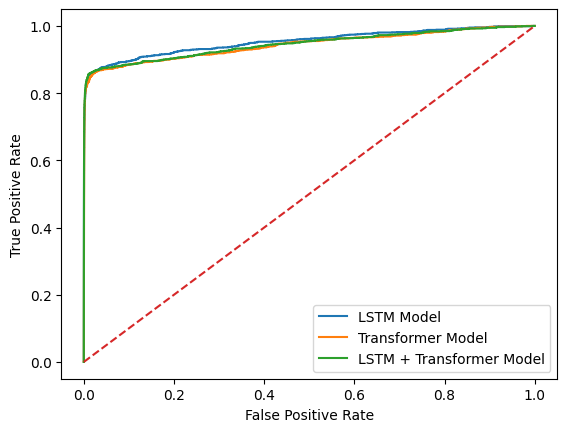

In [ ]:
# ROC SCORES TABLE


f1, t1, _ = roc_curve(y_test, lstmMetrics["Probs"])
f2, t2, _ = roc_curve(y_test, tsfMetrics["Probs"])
f3, t3, _ = roc_curve(y_test, lstmTsfMetrics["Probs"])


plt.plot(f1, t1, label = "LSTM Model")
plt.plot(f2, t2, label = "Transformer Model")
plt.plot(f3, t3, label = "LSTM + Transformer Model")

plt.plot([0,1], [0,1], "--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")


plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


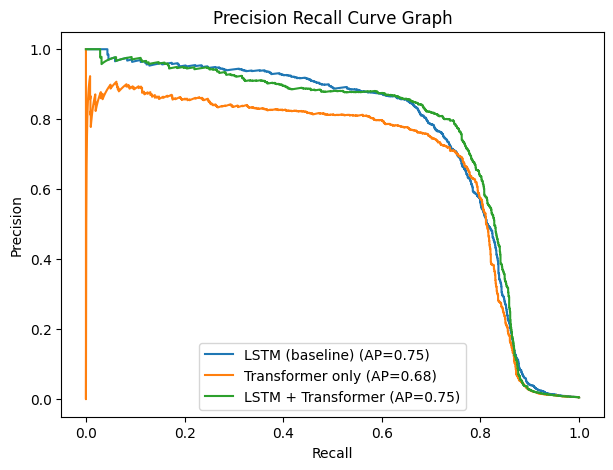

In [ ]:
# Precision / Recall Curves


fig, ax = plt.subplots(figsize = (7,5))

for r in [lstmMetrics, tsfMetrics,lstmTsfMetrics]:
  prec, rec, _ = precision_recall_curve(y_test, r["Probs"])
  ax.plot(rec, prec, label=f"{r["model name"]} (AP={r["Precision"]:.2f})")


ax.set_title("Precision Recall Curve Graph")
ax.set_xlabel("Recall")

ax.set_ylabel("Precision")

ax.legend()

plt.show()

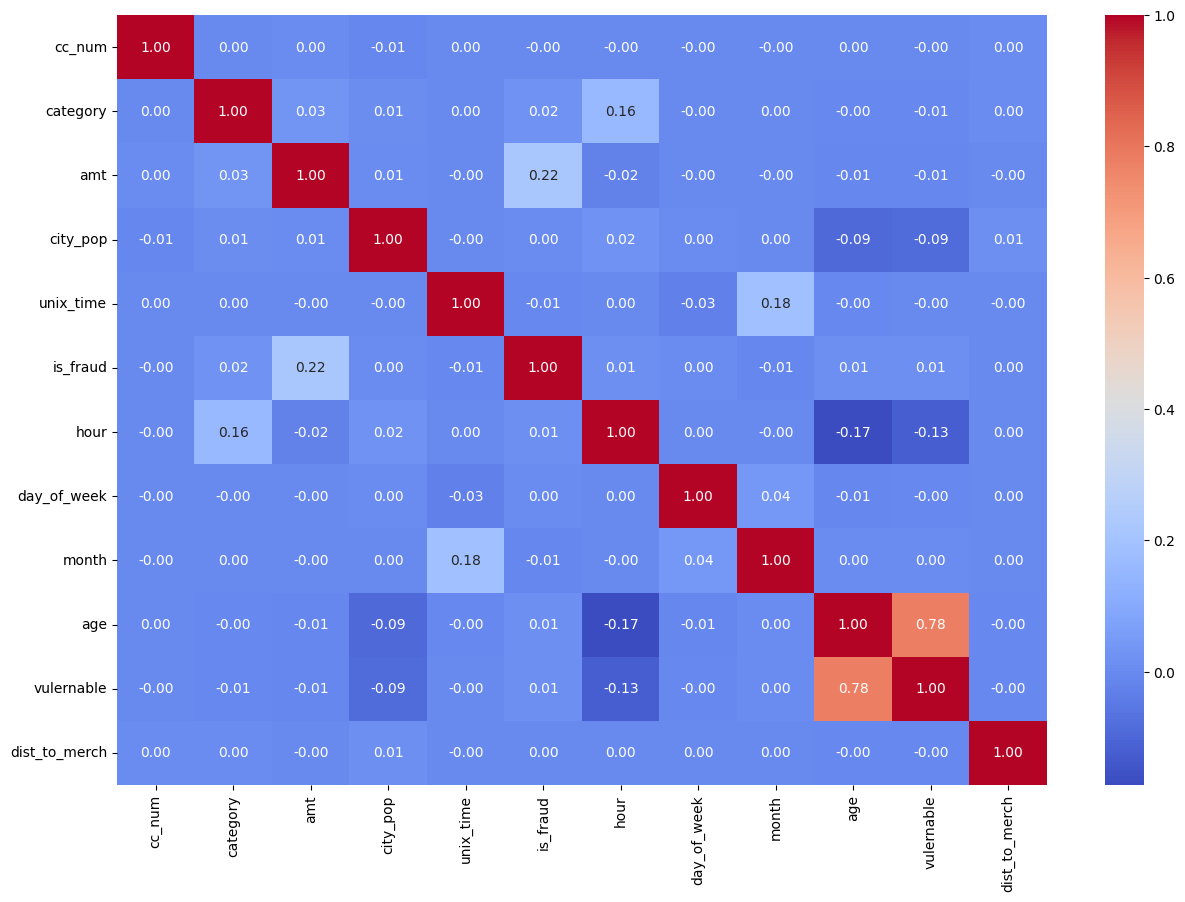

In [ ]:
#heat map of how everything is related to each other.


plt.figure(figsize=(15,10))
sns.heatmap(pp_data.corr(), cmap = "coolwarm", fmt = ".2f", annot=True)

plt.show()

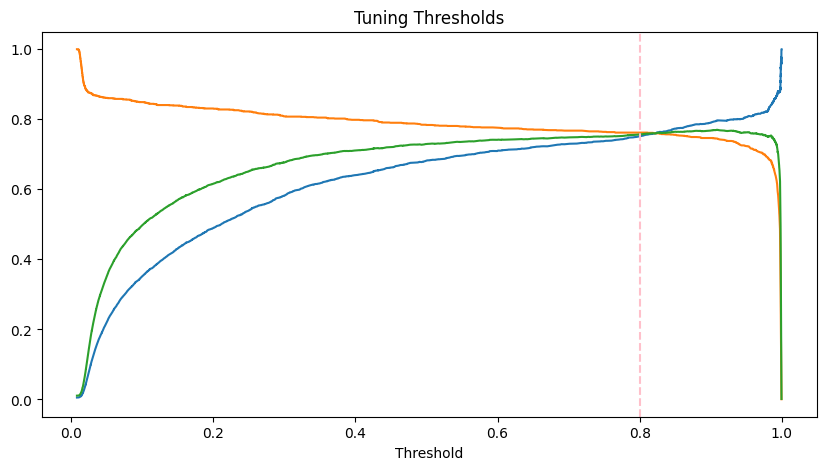

In [ ]:
#Threshold Tuning


prec, rec, thres = precision_recall_curve(y_test, lstmTsfMetrics["Probs"] )

f1Score = 2* (prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1] + 0.0000001)

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(thres, prec[:-1], label= "Precision")

ax.plot(thres, rec[:-1], label= "Recall")

ax.plot(thres, f1Score, label="F1")

ax.axvline(0.8, color="pink", linestyle="--", label="Default (0.5)")

ax.set_title("Tuning Thresholds")

ax.set_xlabel("Threshold")

plt.show()

In [ ]:
### DEMO PORTION - Real Transaction tested

real = np.where(y_test==0)[0][0]
s = X_test_tensor[real].unsqueeze(0).to(device)

lstmTSF.eval()

with torch.no_grad():

  p = torch.sigmoid(lstmTSF(s)).item()



print(f"Chance of this transaction being fraudulent: {p: .2f}")
print(f"Predicted: {"FRAUD" if p >.50 else "REAL"}")
print(f"Actual: Real")



Chance of this transaction being fraudulent:  0.03
Predicted: REAL
Actual: Real


In [ ]:
### DEMO PORTION

fake = np.where(y_test==1)[0][0]
s = X_test_tensor[fake].unsqueeze(0).to(device)

lstmTSF.eval()

with torch.no_grad():

  p = torch.sigmoid(lstmTSF(s)).item()

print(f"Chance of this transaction being fraudulent: {p: .2f}")
print(f"Predicted: {"FRAUD" if p >.50 else "REAL"}")
print(f"Actual: Fraud")


Chance of this transaction being fraudulent:  1.00
Predicted: FRAUD
Actual: Fraud
